### Actividad práctica

1. Generación del conjunto de datos:

Cree un conjunto de datos sintético bidimensional (una variable independiente x y una
variable dependiente y) siguiendo el modelo:

y= 2 + 4(5x−1)(4x−2)(x−0.8)2 + ε

donde x ∼U(0.1, 1) y ε ∼N(0, σ) es ruido gaussiano con media cero y desviación estándar
σ. Se sugiere usar σ = 0.5. Genere al menos 200 observaciones. La siguiente figura muestra
un ejemplo del modelo para los datos sintéticos. Esta figura se realizó con el lenguaje R y se
define una semilla con set.seed(42).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Función generadora

np.random.seed(42)

def generador(n=200, sigma=0.5):
    x = np.random.uniform(0.1, 1, n)
    epsilon = np.random.normal(0, sigma, n)
    y = 2 + (4*(5*x-1))*(4*x-2)*(x-0.8)**2 + epsilon

    return x, y

X, y = generador(n=200, sigma=0.5)


In [3]:
# Función verdadera

def funcion_verdadera(x):
    return 2 + (4*(5*x-1))*(4*x-2)*(x-0.8)**2

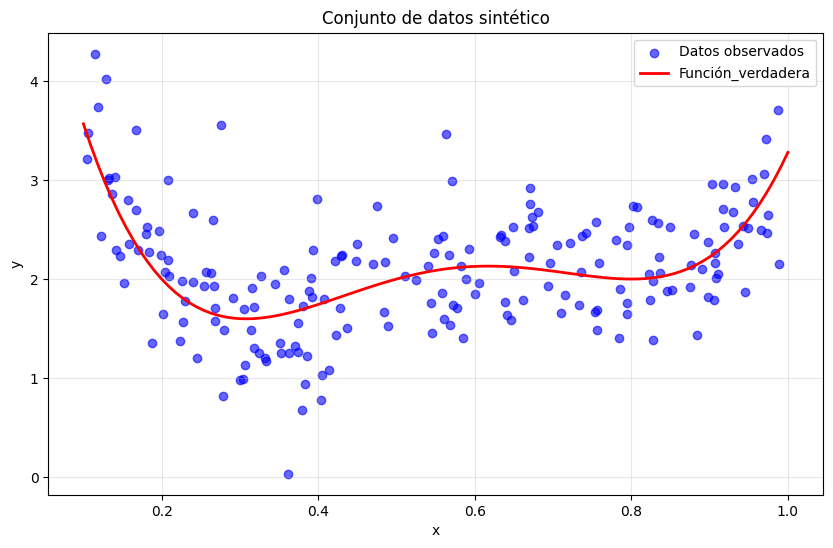

In [4]:
# Visualización de los datos

plt.figure(figsize=(10, 6))
x_plot = np.linspace(0.1, 1, 100)
plt.scatter(X, y, alpha=0.6, label='Datos observados', color='blue')
plt.plot(x_plot, funcion_verdadera(x_plot), 'r-', linewidth=2, label='Función_verdadera')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Conjunto de datos sintético')
plt. legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# División del conjunto de datos

def dividir_datos(X, y):
    n = len(X)
    indices = np.random.permutation(n)

    # 60% entrenamiento
    train_end = int(n * 0.6)

    # 20% validación
    val_end = int(n * 0.8)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    return (X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx])

X_train, y_train, X_val, y_val, X_test, y_test = dividir_datos(X, y)


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def ajustar_modelo_pol (X_train, y_train, grado):
    '''
    Función que utiliza una regresión lineal para encontrar los coeficientes del polinomio que mejor se ajustan a los datos

    '''
    poly = PolynomialFeatures(degree=grado)                     
    X_poly = poly.fit_transform(X_train.reshape(-1, 1))     # Convierte "X_train" en una matriz de (n, 1)
    modelo = LinearRegression()                             # Se crea el modelo
    modelo.fit(X_poly, y_train)                             # Se entrena el modelo
    return modelo, poly

def predecir(modelo, poly, X):
    '''
    Realiza predicciones usando el modelo polinomial

    '''
    X_poly = poly.transform(X.reshape(-1, 1))
    return modelo.predict(X_poly)

def calcular_mse(modelo, poly, X, y):
    '''
    Calcula el error cuadrático medio

    '''
    y_pred = predecir(modelo, poly, X)
    return mean_squared_error(y, y_pred)


In [7]:
# Grados a evaluar
grados = [1, 3, 5, 7, 9, 11, 13, 15, 17]

errores_train = []
errores_val = []
errores_test = []
modelos = {}


for grado in grados:
    modelo, poly = ajustar_modelo_pol(X_train, y_train, grado)
    modelos[grado] = (modelo, poly)

    mse_train = calcular_mse(modelo, poly, X_train, y_train)
    mse_val = calcular_mse(modelo, poly, X_val, y_val)
    mse_test = calcular_mse(modelo, poly, X_test, y_test)

    errores_train.append(mse_train)
    errores_val.append(mse_val)
    errores_test.append(mse_test)

    print(f"\nGrado: {grado}")
    print(f" MSE Entrenamiento : { mse_train : .4f} ")
    print(f" MSE Validación : { mse_val : .4f} ")
    print(f" MSE Prueba : { mse_test : .4f} ")


Grado: 1
 MSE Entrenamiento :  0.4194 
 MSE Validación :  0.4567 
 MSE Prueba :  0.3092 

Grado: 3
 MSE Entrenamiento :  0.2726 
 MSE Validación :  0.3521 
 MSE Prueba :  0.2557 

Grado: 5
 MSE Entrenamiento :  0.2127 
 MSE Validación :  0.2784 
 MSE Prueba :  0.2418 

Grado: 7
 MSE Entrenamiento :  0.2082 
 MSE Validación :  0.2921 
 MSE Prueba :  0.2549 

Grado: 9
 MSE Entrenamiento :  0.2030 
 MSE Validación :  0.2987 
 MSE Prueba :  0.2544 

Grado: 11
 MSE Entrenamiento :  0.2010 
 MSE Validación :  0.3248 
 MSE Prueba :  0.2625 

Grado: 13
 MSE Entrenamiento :  0.1932 
 MSE Validación :  0.3234 
 MSE Prueba :  0.2811 

Grado: 15
 MSE Entrenamiento :  0.1901 
 MSE Validación :  0.3208 
 MSE Prueba :  0.2827 

Grado: 17
 MSE Entrenamiento :  0.1855 
 MSE Validación :  0.3392 
 MSE Prueba :  0.2722 


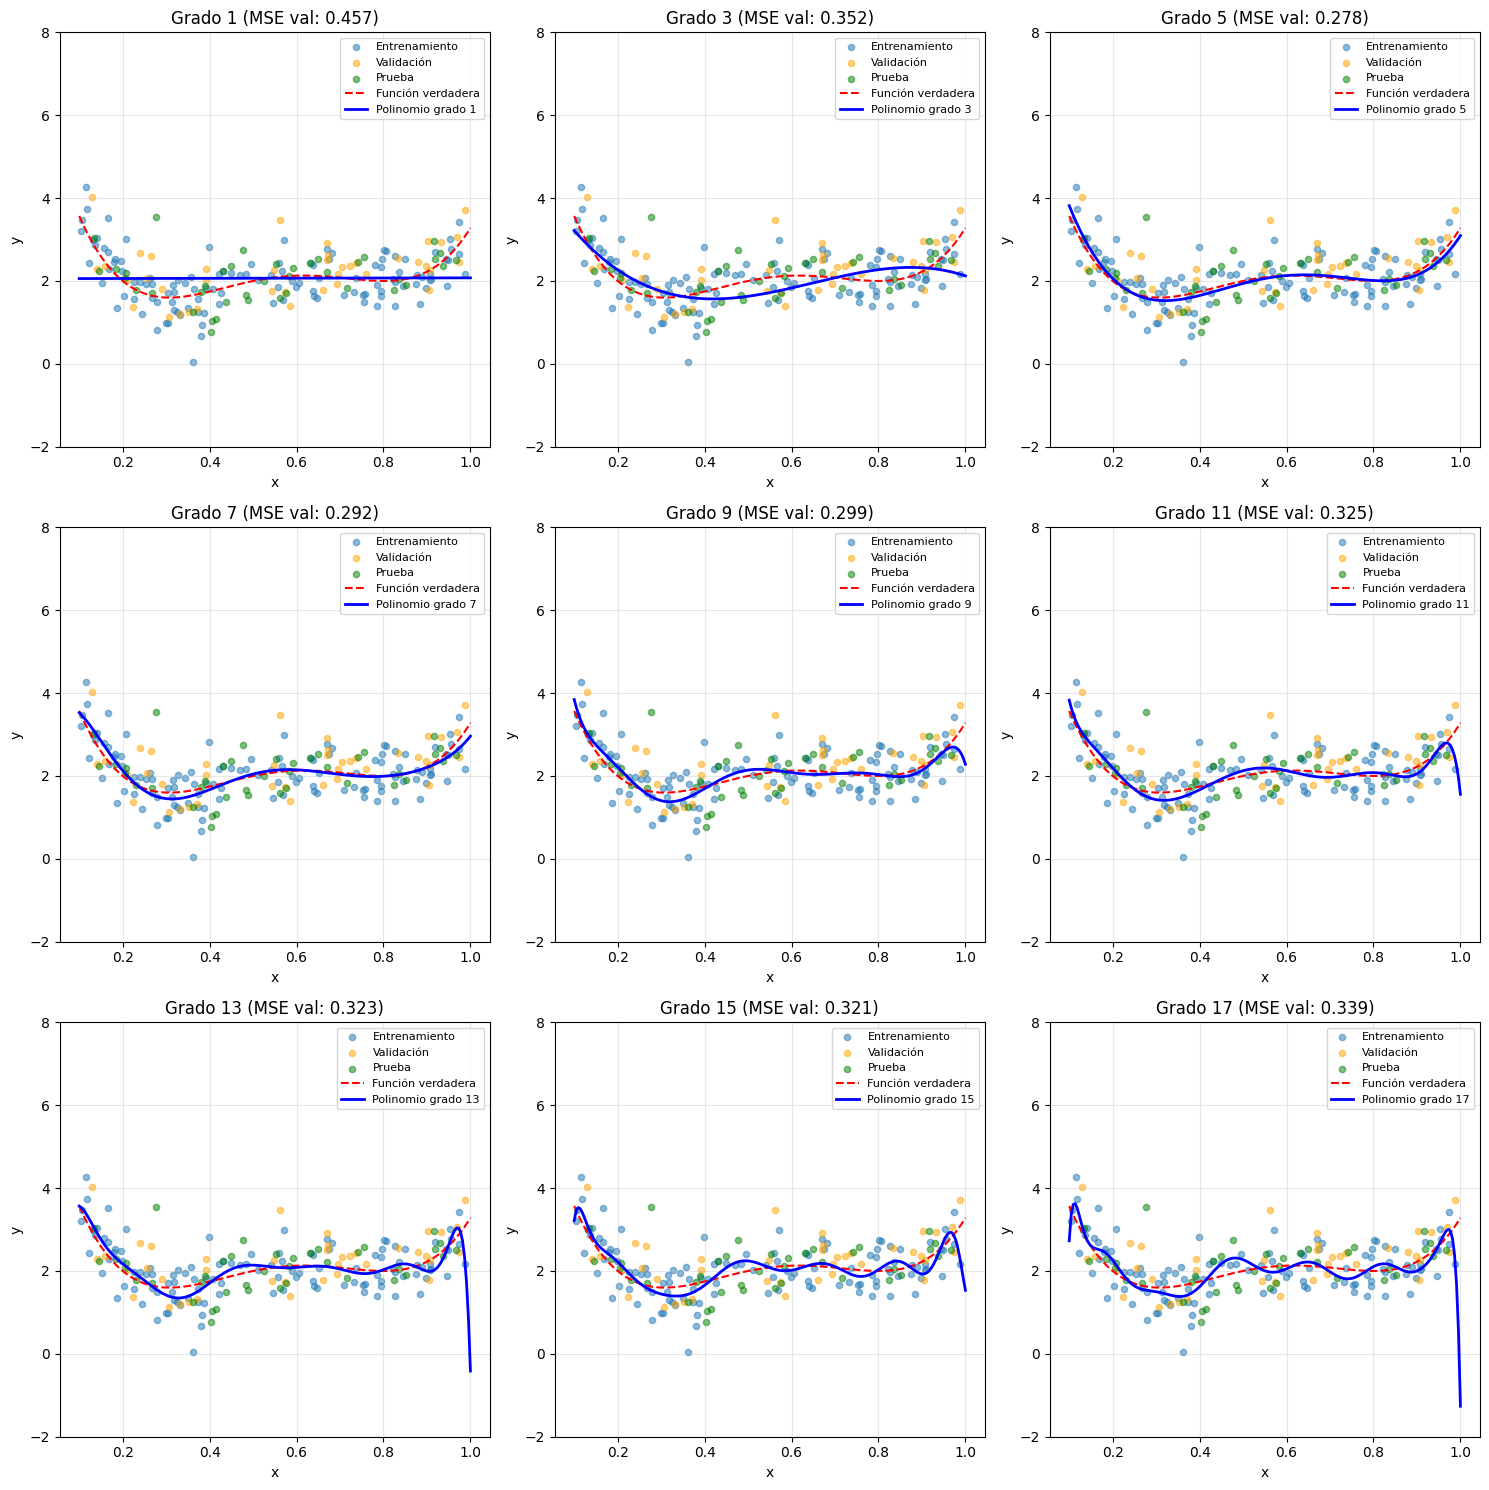

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

x_plot = np.linspace(0.1, 1, 200)

for i, grado in enumerate(grados):
    ax = axes[i]
    modelo, poly = modelos[grado]
    y_plot = predecir(modelo, poly, x_plot)

    ax.scatter(X_train, y_train, alpha=0.5, label='Entrenamiento', s=20)
    ax.scatter(X_val, y_val, alpha=0.5, label='Validación', s=20, color='orange')
    ax.scatter(X_test, y_test, alpha=0.5, label='Prueba', s=20, color='green')

    ax.plot(
        x_plot,
        funcion_verdadera(x_plot),
        'r--',
        linewidth=1.5,
        label='Función verdadera'
    )

    ax.plot(
        x_plot,
        y_plot,
        'b-',
        linewidth=2,
        label=f'Polinomio grado {grado}'
    )

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Grado {grado} (MSE val: {errores_val[i]:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-2, 8])


plt.tight_layout()
plt.show()

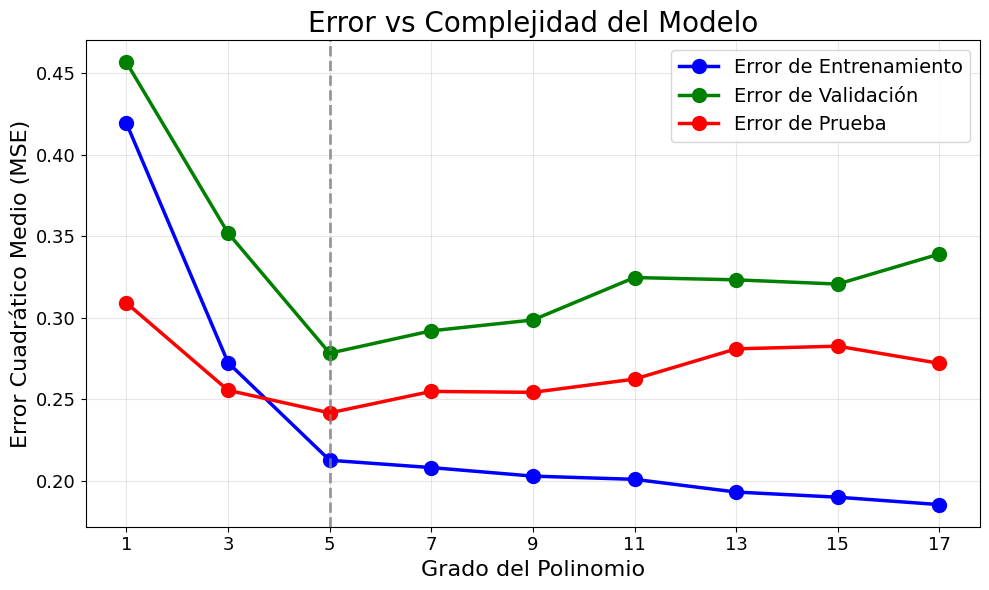

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Curvas de error
plt.plot(
    grados,
    errores_train,
    'o-',
    color='blue',
    linewidth=2.5,
    markersize=10,
    label='Error de Entrenamiento'
)

plt.plot(
    grados,
    errores_val,
    'o-',
    color='green',
    linewidth=2.5,
    markersize=10,
    label='Error de Validación'
)

plt.plot(
    grados,
    errores_test,
    'o-',
    color='red',
    linewidth=2.5,
    markersize=10,
    label='Error de Prueba'
)

# Línea vertical indicando el mejor grado
mejor_grado = 5
plt.axvline(
    x=mejor_grado,
    color='gray',
    linestyle='--',
    linewidth=2,
    alpha=0.8
)

# Título y etiquetas
plt.title('Error vs Complejidad del Modelo', fontsize=20)
plt.xlabel('Grado del Polinomio', fontsize=16)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=16)

# Ticks del eje X
plt.xticks(grados, fontsize=13)
plt.yticks(fontsize=13)

# Cuadrícula
plt.grid(True, alpha=0.3)

# Leyenda
plt.legend(fontsize=14)

# Ajustar márgenes
plt.tight_layout()

# Mostrar
plt.show()

In [10]:
from sklearn.model_selection import KFold
import numpy as np

# Número de folds
k = 5

# Configuración de K-Fold
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

errores_cv = []
errores_cv_std = []

# Combinar los conjuntos de entrenamiento y validación
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

# Evaluar cada grado del polinomio
for grado in grados:

    cv_scores = []

    # Recorrer cada fold
    for train_idx, val_idx in kfold.split(X_cv):

        # Separar entrenamiento y validación del fold
        X_fold_train = X_cv[train_idx]
        X_fold_val = X_cv[val_idx]

        y_fold_train = y_cv[train_idx]
        y_fold_val = y_cv[val_idx]

        # Entrenar el modelo
        modelo, poly = ajustar_modelo_pol(
            X_fold_train,
            y_fold_train,
            grado
        )

        # Calcular el MSE del fold
        mse = calcular_mse(
            modelo,
            poly,
            X_fold_val,
            y_fold_val
        )

        cv_scores.append(mse)

    # Promedio y desviación estándar del MSE
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)

    errores_cv.append(cv_mean)
    errores_cv_std.append(cv_std)

    print(f"\nGrado: {grado}")
    print(f"MSE promedio (CV): {cv_mean:.4f}")
    print(f"Desviación estándar: {cv_std:.4f}")


Grado: 1
MSE promedio (CV): 0.4309
Desviación estándar: 0.1295

Grado: 3
MSE promedio (CV): 0.3090
Desviación estándar: 0.0922

Grado: 5
MSE promedio (CV): 0.2551
Desviación estándar: 0.0592

Grado: 7
MSE promedio (CV): 0.2583
Desviación estándar: 0.0588

Grado: 9
MSE promedio (CV): 0.2656
Desviación estándar: 0.0571

Grado: 11
MSE promedio (CV): 0.2755
Desviación estándar: 0.0567

Grado: 13
MSE promedio (CV): 0.2782
Desviación estándar: 0.0535

Grado: 15
MSE promedio (CV): 0.2847
Desviación estándar: 0.0669

Grado: 17
MSE promedio (CV): 0.2866
Desviación estándar: 0.0655


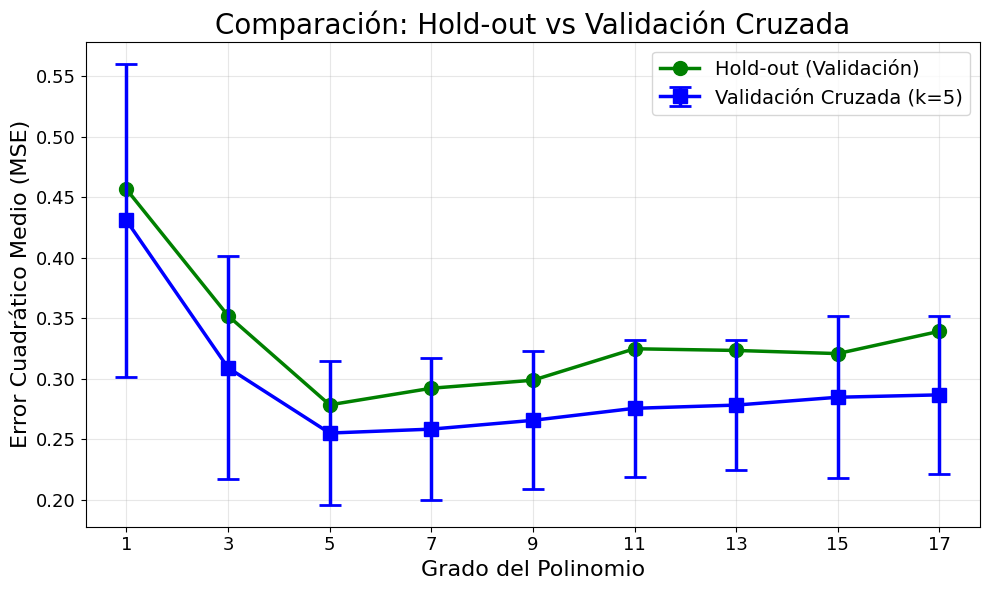

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Hold-out (Validación)
plt.plot(
    grados,
    errores_val,
    'o-',
    color='green',
    linewidth=2.5,
    markersize=10,
    label='Hold-out (Validación)'
)

# Validación Cruzada con barras de error
plt.errorbar(
    grados,
    errores_cv,
    yerr=errores_cv_std,
    fmt='s-',
    color='blue',
    linewidth=2.5,
    markersize=10,
    capsize=8,
    elinewidth=2.5,
    capthick=2,
    label='Validación Cruzada (k=5)'
)

plt.title('Comparación: Hold-out vs Validación Cruzada', fontsize=20)
plt.xlabel('Grado del Polinomio', fontsize=16)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=16)

plt.xticks(grados, fontsize=13)
plt.yticks(fontsize=13)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
# Función para calcular la curva de aprendizaje
def calcular_curva_aprendizaje(X_train, y_train, X_val, y_val, grado, tamanos):
    """
    Calcula los errores de entrenamiento y validación para
    diferentes tamaños del conjunto de entrenamiento.

    Parámetros:
        X_train, y_train : datos de entrenamiento
        X_val, y_val     : datos de validación
        grado            : grado del polinomio
        tamanos          : lista con los tamaños de muestra a evaluar

    Regresa:
        errores_train_curva : lista con los MSE de entrenamiento
        errores_val_curva   : lista con los MSE de validación
    """

    errores_train_curva = []
    errores_val_curva = []

    # Evaluar cada tamaño del conjunto de entrenamiento
    for n in tamanos:

        # Seleccionar únicamente las primeras n observaciones
        X_subset = X_train[:n]
        y_subset = y_train[:n]

        # Entrenar el modelo con el subconjunto
        modelo, poly = ajustar_modelo_pol(X_subset, y_subset, grado)

        # Calcular el error en entrenamiento y validación
        mse_train = calcular_mse(modelo, poly, X_subset, y_subset)
        mse_val = calcular_mse(modelo, poly, X_val, y_val)

        # Guardar los errores
        errores_train_curva.append(mse_train)
        errores_val_curva.append(mse_val)

    return errores_train_curva, errores_val_curva


# Tamaños del conjunto de entrenamiento que se evaluarán
tamanos = [20, 40, 60, 80, 100, 120]

# Modelos a comparar
grados_comparar = [5, 11]   # Grado 5 = simple, Grado 11 = complejo

# Calcular las curvas de aprendizaje para ambos modelos
for grado in grados_comparar:

    errores_train_curva, errores_val_curva = calcular_curva_aprendizaje(
        X_train,
        y_train,
        X_val,
        y_val,
        grado,
        tamanos
    )

    print(f"\nGrado {grado}")
    print("MSE entrenamiento:", errores_train_curva)
    print("MSE validación:", errores_val_curva)


Grado 5
MSE entrenamiento: [0.10924801001759894, 0.13184772876430284, 0.18339802836092006, 0.19354004571543146, 0.2014705051991668, 0.21273150156120804]
MSE validación: [0.28562831330809335, 0.28676055821904256, 0.28245450485429074, 0.29202847682195887, 0.2783383017057982, 0.2783835925115385]

Grado 11
MSE entrenamiento: [0.09976981063518668, 0.11237414307482056, 0.16091034502876617, 0.17967429201702662, 0.19020203290207402, 0.20103332917404548]
MSE validación: [0.2922746195342582, 0.2927708595016659, 0.2864198798546293, 0.33425731163721667, 0.32969867156749577, 0.3247703604094475]


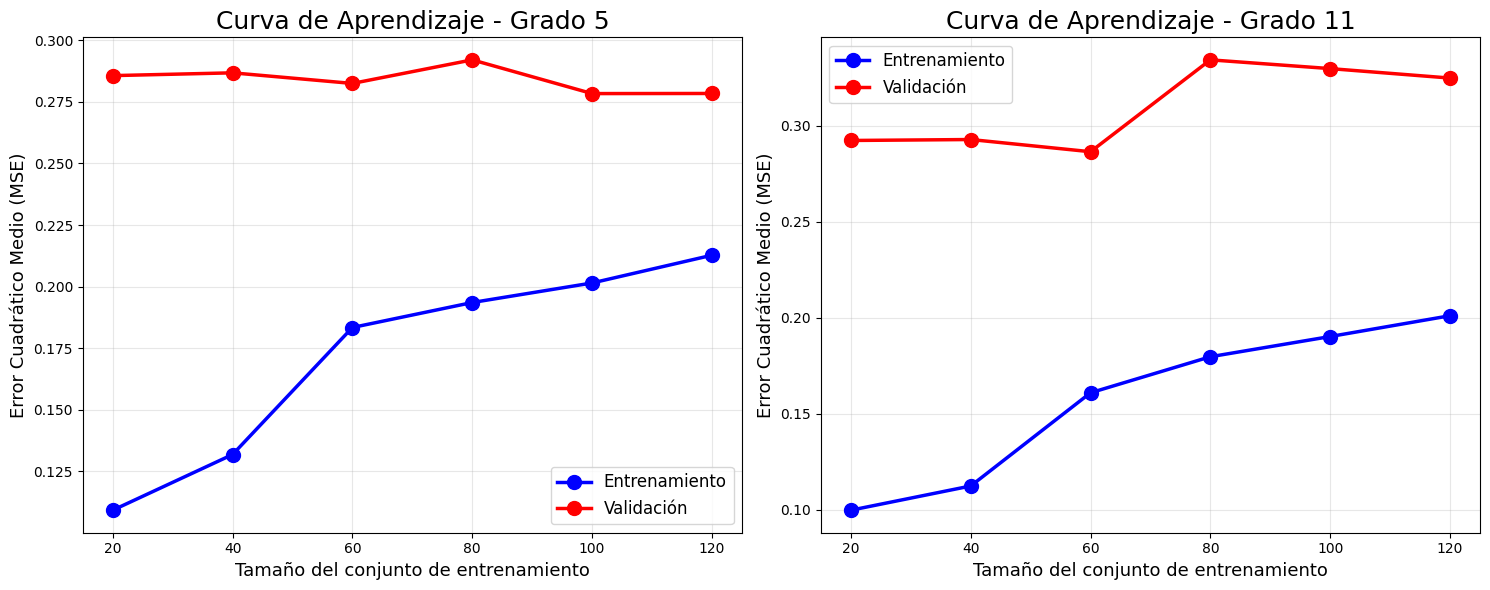

In [13]:
# Modelos a comparar
grados_comparar = [5, 11]

# Crear la figura con dos subgráficas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, grado in enumerate(grados_comparar):

    # Calcular la curva de aprendizaje
    errores_train_curva, errores_val_curva = calcular_curva_aprendizaje(
        X_train,
        y_train,
        X_val,
        y_val,
        grado,
        tamanos
    )

    ax = axes[i]

    # Error de entrenamiento
    ax.plot(
        tamanos,
        errores_train_curva,
        'o-',
        color='blue',
        linewidth=2.5,
        markersize=10,
        label='Entrenamiento'
    )

    # Error de validación
    ax.plot(
        tamanos,
        errores_val_curva,
        'o-',
        color='red',
        linewidth=2.5,
        markersize=10,
        label='Validación'
    )

    # Configuración de la gráfica
    ax.set_title(f'Curva de Aprendizaje - Grado {grado}', fontsize=18)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=13)
    ax.set_ylabel('Error Cuadrático Medio (MSE)', fontsize=13)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)

# Ajustar espacios entre gráficas
plt.tight_layout()

# Mostrar
plt.show()